In [27]:
import pandas as pd

In [28]:
df = pd.read_csv("./txo_2025-09-17_1334_2025-10_quotes.csv")
df = df[['underlying_index', 'strike_price',
       'call_bid', 'call_ask', 'call_last','put_bid',
       'put_ask', 'put_last']]
df['S-K'] = df['underlying_index'].round() - df['strike_price']
df['net_premium@last'] = df['call_last'] - df['put_last']
df['breakeven@last'] = df['strike_price'] + df['net_premium@last']
df['net_premium@bid_ask'] = df['call_bid'] - df['put_ask']
df['breakeven@bid_ask'] = df['strike_price'] + df['net_premium@bid_ask']
df['spread@last'] = df['S-K'] - df['net_premium@last']
df['spread@bid_ask'] = df['S-K'] - df['net_premium@bid_ask']
df[['call_bid', 'call_ask', 'call_last', 'put_bid', 'put_ask', 'put_last',
    'underlying_index', 'strike_price', 'S-K','net_premium@last', 'net_premium@bid_ask',
    'spread@last', 'spread@bid_ask']]

,call_bid,call_ask,call_last,put_bid,put_ask,put_last,underlying_index,strike_price,S-K,net_premium@last,net_premium@bid_ask,spread@last,spread@bid_ask
0,930.0,965.0,980.0,271.0,285.0,280.0,25432.11,24800,632.0,700.0,645.0,-68.0,-13.0
1,525.0,970.0,905.0,306.0,310.0,310.0,25432.11,24900,532.0,595.0,215.0,-63.0,317.0
2,805.0,810.0,810.0,322.0,337.0,333.0,25432.11,25000,432.0,477.0,468.0,-45.0,-36.0
3,725.0,745.0,735.0,352.0,366.0,365.0,25432.11,25100,332.0,370.0,359.0,-38.0,-27.0
4,660.0,675.0,670.0,390.0,398.0,411.0,25432.11,25200,232.0,259.0,262.0,-27.0,-30.0
5,600.0,610.0,605.0,420.0,433.0,432.0,25432.11,25300,132.0,173.0,167.0,-41.0,-35.0
6,530.0,545.0,545.0,456.0,471.0,456.0,25432.11,25400,32.0,89.0,59.0,-57.0,-27.0
7,477.0,487.0,486.0,500.0,515.0,510.0,25432.11,25500,-68.0,-24.0,-38.0,-44.0,-30.0
8,427.0,428.0,428.0,540.0,560.0,550.0,25432.11,25600,-168.0,-122.0,-133.0,-46.0,-35.0
9,370.0,380.0,380.0,590.0,610.0,625.0,25432.11,25700,-268.0,-245.0,-240.0,-23.0,-28.0


# 筆記

## Put-Call Parity
根據 Put-Call Parity 及**不考慮手續費、利率等情況**下，當
> $$標的指數（S） - Strike（K） \ne Call- Put$$

表示有套利空間。

當 $S-K<C-P$ 時，可以 Short（C-P）組合，Long 標的資產（S）（Short 高價值，Long 低價值），以鎖定利潤；

當 $S-K>C-P$ 時，可以 Long（C-P）組合，Short 標的資產（S）。

## Synthetic Futures / 合成期貨
Synthetic futures 是由兩口相同的 K 組出等同 Futures 效果的商品。當要 Long / Short S 時，也可以用 Synthetic futures 達成相同效果。因此，
- 當 $S-K<C-P$ 時，Long S 可以由 `Buy Call + Sell Put` 組出達到 Long futures 的效果；
- 當 $S-K>C-P$ 時，Short S 可以由 `Sell Call + Buy Put` 組出達到 Short futures 的效果；

### Box Spread
Box Spread 是由`Long synthetic futures`和`Short synthetic futures`組合的套利策略。

當 $[K_1+(C_1 - P_1)]-K_2 < (C_2 - P_2)$，表示標的價值低（$K_1+(C_1 - P_1)$），因此要 Long $K_1$, Short $K_2$，其組合為
- Call 側：Long $K_1$ Call + Short $K_2$ Call
- Put 側：Short $K_1$ Put + Long $K_2$ Put

當 $[K_1+(C_1 - P_1)]-K_2 > (C_2 - P_2)$，表示標的價值高，因此要 Short $K_1$, Long $K_2$，其組合為
- Call 側：Short $K_1$ Call + Long $K_2$ Call
- Put 側：Long $K_1$ Put + Short $K_2$ Put

因為不管是哪個 $K$ 組合成的合成期貨，其損益曲線理論上是重疊，所以在理解 Long / Short K 時，也能理解為：
- $K_1 合成期貨價值 < K_2 合成期貨價值$ 時，要 Long $K_1$，Short $K_2$；
- $K_1 合成期貨價值 > K_2 合成期貨價值$ 時，要 Short $K_1$，Long $K_2$。

#### 範例
| Strike（K） | Net Premium（C-P） |
| -: | -: |
| $K_1=45,000$ | 1020 |
| $K_2=46,000$  | 30 |

因為 `(45,000 + 1020) - 46,000 < 30`，所以可以 Long $K_1$，Short $K_2$
- Call 側：Long 45,000C, Short 46,000C
- Put 側：Short 45,000P, Long 46,000P

#### Long Box & Short Box
| 項目 | Long Box | Short Box |
| - | - | - |
| 合成期貨組合 | 低 K 多頭 + 高 K 空頭 | 低 K 空頭 + 高 K 多頭 |
| Call 側 | Long $K_1$ Call + Short $K_2$ Call | Short $K_1$ Call + Long $K_2$ Call | 
| Put 側 | Short $K_1$ Put + Long $K_2$ Put | Long $K_1$ Put + Short $K_2$ Put | 
| 適用時機 | 合成期貨價差 < 履約價差（低估）| 合成期貨價差 > 履約價差（高估）| 
| 現金流 | 淨支出（需先投入資金）| 淨收入（先收取權利金）|

# 題目一：
> 用履約價相同的買賣權，可以組合出等同
於直接放空此指數的商品。而若兩個不同
履約價組出之商品損益曲線不完全重合，
即會產生套利空間，試從此報價資料中找
到一組套利空間，請將此兩條獲利曲線繪
在同一張圖上並將圖貼到報告中，另說明
該如何買賣這些選擇權且獲得多少套利空
間（假設無交易成本，亦無滑價或流動性
問題） ），試解釋此套利機會可能無法實現
的原因 。

在當前報價中，以`成交`為 Premium 時，在 $K=24,800$ 有最大 Spread，所以可以採取 Long 指數，Short $K=24,800$ 的策略。

因為套利皆要以 Options 操作，因此在 $K=25,900$ 建立多頭合成期貨，以代表 Long 指數的部分。

最後，整個套利策略的選擇權組合為
- Call 側：Short 24800C + Long 25900C
- Put 側：Long 24800P + Short 25900P

理論套利=$(980-280-283+745) - (25900-24800)=+62$

由於實務上 Premium 要使用 Bid/Ask，所以如果採用相同的策略，則

套利=$(930-285-290+700) - (25900-24800)=-45$

由此結果可知，實務上這個策略無法套利且如果在考量手續費時，此策略將虧損更多。

In [29]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
from matplotlib.transforms import Bbox, ScaledTranslation


def _display_paths(artist):
    """Return an artist's paths in rendered (display) coordinates."""
    return [path.transformed(artist.get_transform()) for path in artist.get_paths()]


def _trim_path_at_anchor(path, anchor, radius=7):
    """The annotation leader may touch only at its own anchor."""
    vertices = path.vertices
    keep = np.hypot(vertices[:, 0] - anchor[0], vertices[:, 1] - anchor[1]) > radius
    trimmed = vertices[keep]
    return Path(trimmed) if len(trimmed) > 1 else None


def _box_distance(first, second):
    dx = max(first.x0 - second.x1, second.x0 - first.x1, 0)
    dy = max(first.y0 - second.y1, second.y0 - first.y1, 0)
    return float(np.hypot(dx, dy))


def _path_box_distance(path, bbox):
    """Minimum display-coordinate distance from a polyline to a text box."""
    if path.intersects_bbox(bbox, filled=False):
        return 0.0
    corners = np.array([
        [bbox.x0, bbox.y0], [bbox.x0, bbox.y1],
        [bbox.x1, bbox.y0], [bbox.x1, bbox.y1],
    ])
    best = np.inf
    for start, end in zip(path.vertices[:-1], path.vertices[1:]):
        segment = end - start
        length_sq = float(segment @ segment)
        if length_sq == 0:
            best = min(best, _box_distance(
                Bbox.from_extents(*start, *start), bbox
            ))
            continue
        t = np.clip(((corners - start) @ segment) / length_sq, 0, 1)
        closest = start + t[:, None] * segment
        best = min(best, float(np.min(np.linalg.norm(corners - closest, axis=1))))
    return best


def _move_nearby_tick_labels(fig, ax, values):
    """Keep required but closely-spaced y tick labels readable."""
    labels = ax.get_yticklabels()
    positions = ax.get_yticks()
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    for left, right in zip(range(len(labels) - 1), range(1, len(labels))):
        first = labels[left].get_window_extent(renderer)
        second = labels[right].get_window_extent(renderer)
        if first.overlaps(second):
            direction = -1 if positions[left] < positions[right] else 1
            labels[left].set_transform(
                labels[left].get_transform()
                + ScaledTranslation(0, direction * 11 / 72, fig.dpi_scale_trans)
            )
            labels[right].set_transform(
                labels[right].get_transform()
                - ScaledTranslation(0, direction * 11 / 72, fig.dpi_scale_trans)
            )
            fig.canvas.draw()


def _place_annotations_globally(ax, specs, protected):
    """Choose a collision-free annotation layout from all candidate combinations."""
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    static_artists = [*ax.get_yticklabels(), ax.xaxis.label, ax.yaxis.label, ax.title]
    static_boxes = [
        artist.get_window_extent(renderer).padded(4)
        for artist in static_artists if artist.get_visible() and artist.get_text()
    ]
    directions = [(-1, -1), (1, -1), (-1, 1), (1, 1)]
    offsets = [
        (horizontal * distance, vertical * distance)
        for distance in (38, 62, 90)
        for horizontal, vertical in directions
    ]

    def make_annotation(text, price, offset):
        return ax.annotate(
            text, xy=(price, 0), xytext=offset, textcoords='offset points',
            ha='left' if offset[0] > 0 else 'right',
            va='bottom' if offset[1] > 0 else 'top', clip_on=False,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.88, pad=1.7),
            arrowprops=dict(
                arrowstyle='-', color='gray', linestyle='--', linewidth=1,
                shrinkA=0, shrinkB=0, connectionstyle='arc3,rad=0',
            ),
        )

    candidates = []
    for text, price in specs:
        anchor = ax.transData.transform((price, 0))
        choices = []
        for offset in offsets:
            annotation = make_annotation(text, price, offset)
            fig.canvas.draw()
            bbox = annotation.get_bbox_patch().get_window_extent(renderer).padded(3)
            arrow = annotation.arrow_patch.get_path().transformed(annotation.arrow_patch.get_transform())
            trimmed_arrow = _trim_path_at_anchor(arrow, anchor)
            collisions = int(not (
                fig.bbox.contains(bbox.x0, bbox.y0) and fig.bbox.contains(bbox.x1, bbox.y1)
            ))
            collisions += sum(path.intersects_bbox(bbox, filled=filled)
                              for path, filled in protected)
            collisions += sum(bbox.overlaps(other) for other in static_boxes)
            arrow_collisions = 0 if trimmed_arrow is None else (
                sum(trimmed_arrow.intersects_path(path, filled=filled)
                    for path, filled in protected)
                + sum(trimmed_arrow.intersects_bbox(other) for other in static_boxes)
            )
            collisions += arrow_collisions
            distances = [_path_box_distance(path, bbox) for path, _ in protected]
            distances.extend(_box_distance(bbox, other) for other in static_boxes)
            choices.append({
                'offset': offset, 'bbox': bbox, 'arrow': arrow,
                'trimmed_arrow': trimmed_arrow, 'collisions': int(collisions),
                'line_shortfall': max(0, 10 - min(distances, default=20)),
            })
            annotation.remove()
        candidates.append(choices)

    best_choice = best_score = None
    for choice in itertools.product(range(len(offsets)), repeat=len(specs)):
        selected = [candidates[index][candidate] for index, candidate in enumerate(choice)]
        collisions = sum(item['collisions'] for item in selected)
        line_shortfall = sum(item['line_shortfall'] for item in selected)
        label_shortfall = 0
        for first, second in itertools.combinations(selected, 2):
            collisions += int(first['bbox'].overlaps(second['bbox']))
            collisions += int(first['arrow'].intersects_bbox(second['bbox']))
            collisions += int(second['arrow'].intersects_bbox(first['bbox']))
            if first['trimmed_arrow'] is not None and second['trimmed_arrow'] is not None:
                collisions += int(first['trimmed_arrow'].intersects_path(second['trimmed_arrow']))
            label_shortfall += max(0, 16 - _box_distance(first['bbox'], second['bbox']))
        leader_length = sum(np.hypot(*item['offset']) for item in selected)
        score = (collisions, line_shortfall, label_shortfall, leader_length)
        if best_score is None or score < best_score:
            best_choice, best_score = choice, score
    if best_score is None or best_score[0] != 0:
        raise RuntimeError('No collision-free label layout; enlarge the chart or margins.')
    return [
        make_annotation(text, price, candidates[index][best_choice[index]]['offset'])
        for index, (text, price) in enumerate(specs)
    ]


def _validate_final_layout(fig, ax, annotations, protected):
    """Use rendered geometry to reject any final collision or clipping."""
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    static_artists = [*ax.get_yticklabels(), ax.xaxis.label, ax.yaxis.label, ax.title]
    static_boxes = [
        artist.get_window_extent(renderer).padded(3)
        for artist in static_artists if artist.get_visible() and artist.get_text()
    ]
    for box in static_boxes:
        assert fig.bbox.contains(box.x0, box.y0) and fig.bbox.contains(box.x1, box.y1), \
            'Static chart text extends beyond the canvas.'
    assert not any(first.overlaps(second) for index, first in enumerate(static_boxes)
                   for second in static_boxes[index + 1:]), 'Static chart text overlaps.'
    annotation_boxes = []
    for annotation in annotations:
        bbox = annotation.get_bbox_patch().get_window_extent(renderer).padded(3)
        assert fig.bbox.contains(bbox.x0, bbox.y0) and fig.bbox.contains(bbox.x1, bbox.y1), \
            'An annotation extends beyond the canvas.'
        assert not any(path.intersects_bbox(bbox, filled=filled) for path, filled in protected), \
            'An annotation overlaps a plotted line, guide, axis, or profit area.'
        assert not any(bbox.overlaps(other) for other in static_boxes), \
            'An annotation overlaps static chart text.'
        annotation_boxes.append(bbox)
    for first, second in itertools.combinations(annotation_boxes, 2):
        assert not first.overlaps(second), 'Annotations overlap.'


def plot_short_box(strategy_name, k1, k2):
    """Plot any short box using only the quoted last premiums in ``df``."""
    quotes = df.set_index('strike_price')
    c1, p1 = quotes.loc[k1, ['call_last', 'put_last']].astype(float)
    c2, p2 = quotes.loc[k2, ['call_last', 'put_last']].astype(float)
    net_premium = c1 - p1 - c2 + p2
    locked_profit = net_premium - (k2 - k1)
    assert locked_profit > 0, 'This helper is intended for an arbitrage short box.'

    horizontal_pad = max(250, 0.22 * (k2 - k1))
    prices = np.linspace(k1 - horizontal_pad, k2 + horizontal_pad, 2_001)
    pnl = np.full_like(prices, locked_profit, dtype=float)
    # The dashed legs are payoff-only synthetic futures; premiums stay in ``pnl``.
    long_synthetic = prices - k2
    short_synthetic = k1 - prices
    component_floor = min(long_synthetic.min(), short_synthetic.min())
    component_ceiling = max(long_synthetic.max(), short_synthetic.max())
    ymax = max(net_premium, locked_profit, component_ceiling, 1) * 1.16
    ymin = min(component_floor * 1.16, -max(net_premium, locked_profit, 1) * 0.66)

    fig, ax = plt.subplots(figsize=(13, 9))
    # Buy C(K2) + sell P(K2): long synthetic future; sell C(K1) + buy P(K1): short.
    long_synthetic_line, = ax.plot(
        prices, long_synthetic, color='tab:blue', linestyle='--', linewidth=2.0, zorder=2
    )
    short_synthetic_line, = ax.plot(
        prices, short_synthetic, color='tab:orange', linestyle='--', linewidth=2.0, zorder=2
    )
    pnl_line, = ax.plot(prices, pnl, color='tab:blue', linewidth=2.5, zorder=3)
    profit_fill = ax.fill_between(
        prices, 0, pnl, where=pnl > 0, interpolate=True,
        color='forestgreen', alpha=0.25, zorder=1,
    )
    guides = [
        ax.vlines(strike, 0, locked_profit, color='gray', linestyle='--', linewidth=1.1, zorder=2)
        for strike in (k1, k2)
    ]
    guides.append(ax.hlines(locked_profit, prices.min(), k2, color='gray',
                            linestyle='--', linewidth=1.1, zorder=2))

    ax.set_xlim(prices.min(), prices.max())
    ax.set_ylim(ymin, ymax)
    ax.set_xticks([])
    tick_values = [0, locked_profit, net_premium]
    tick_labels = [
        '0', f'Locked arbitrage profit\n{locked_profit:+,.0f}',
        f'Net premium received\n{net_premium:+,.0f}',
    ]
    ax.set_yticks(tick_values, tick_labels)
    ax.set_title(f'{strategy_name} (Strikes={k1:,.0f} / {k2:,.0f}, Net Premium={net_premium:+,.0f})')
    ax.set_xlabel('Underlying Price at Expiration')
    ax.set_ylabel('Profit / Loss (points)')
    ax.yaxis.set_label_coords(-0.24, 0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position(('data', 0))
    ax.spines['bottom'].set_linewidth(1)
    ax.spines['left'].set_linewidth(1)
    ax.xaxis.set_ticks_position('bottom')
    ax.tick_params(axis='x', length=0)
    ax.xaxis.set_label_coords(0.5, -0.16)
    fig.tight_layout(pad=1.8)
    _move_nearby_tick_labels(fig, ax, tick_values)

    protected = [
        (pnl_line.get_path().transformed(pnl_line.get_transform()), False),
        *[(path, True) for path in _display_paths(profit_fill)],
        *[(path, False) for guide in guides for path in _display_paths(guide)],
        (long_synthetic_line.get_path().transformed(long_synthetic_line.get_transform()), False),
        (short_synthetic_line.get_path().transformed(short_synthetic_line.get_transform()), False),
        (ax.spines['left'].get_path().transformed(ax.spines['left'].get_transform()), False),
        (ax.spines['bottom'].get_path().transformed(ax.spines['bottom'].get_transform()), False),
    ]
    annotations = _place_annotations_globally(
        ax, [(f'Strike\n{k1:,.0f}', k1), (f'Strike\n{k2:,.0f}', k2)], protected
    )
    fig.canvas.draw()
    _validate_final_layout(fig, ax, annotations, protected)
    plt.show()


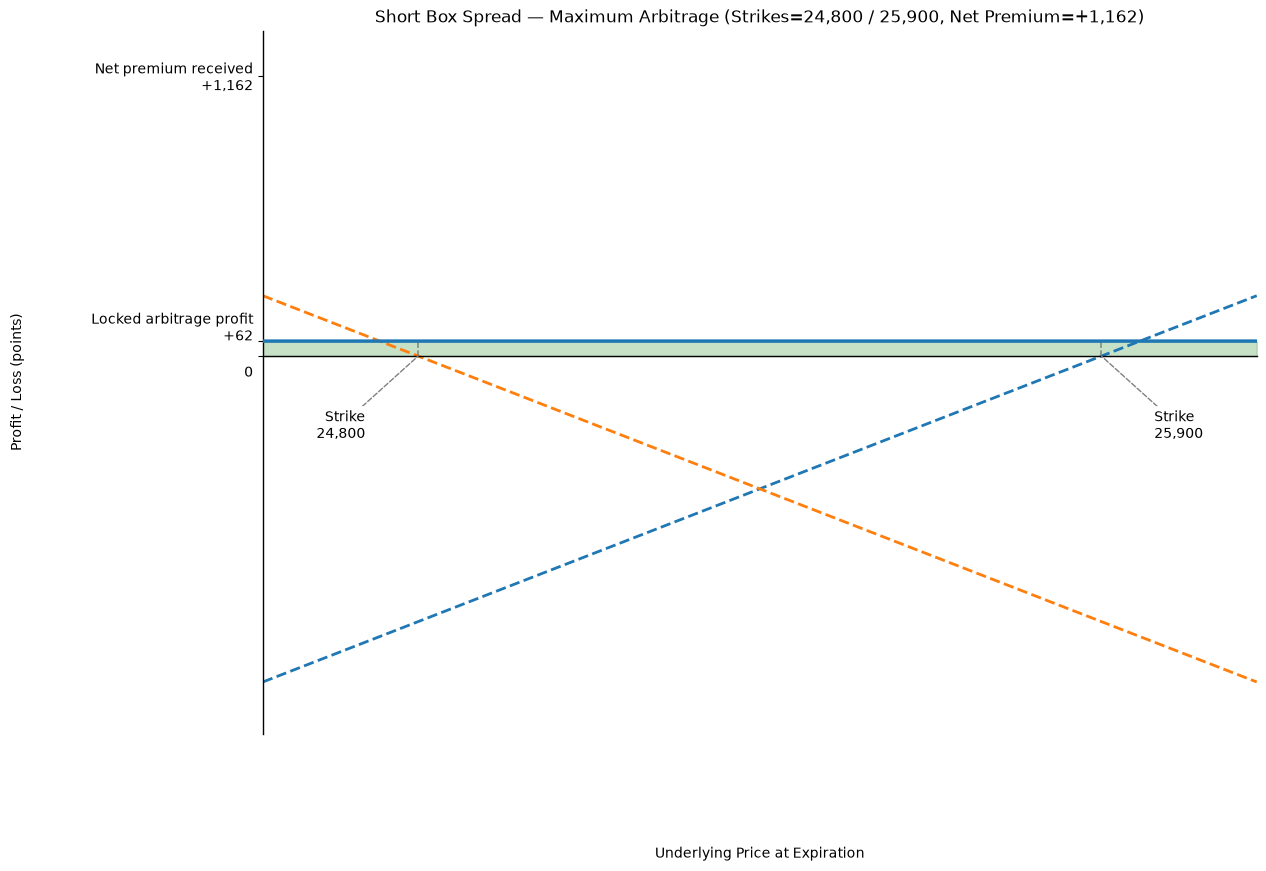

In [30]:
# Maximum arbitrage short box: 24,800 / 25,900.
plot_short_box('Short Box Spread — Maximum Arbitrage', 24_800, 25_900)


# 題目二：
> 假設你已知川普必然會在兩週後降低台灣關稅稅率，使上述選擇權結算時的台灣加權股價指數上漲．且必然出現在 25,650 點以上，試組合出兩組不同的 spread 儘可能在符合上述假設時獲利，請將兩條獲利曲線繪在同一張圖上並將圖貼到報告中，另在報告中簡述你用哪些選擇權組出此組合，並比較兩組合在各結算價位的優劣。

當前為 `25,432` 且確定必然會在 `25,650` 以上，由於方向確定但漲幅不確定，所以使用 Long Spread 和 Short Butterfly 策略。
- Long Call Spread: 賺取指數差。獲利有限，風險有限。
- Short Butterfly: 賺權利金。獲利有限，風險有限。

### Long Call Spread
因為指數必然會在 25,650 以上且要賺取指數差，所以 Short 25600C，Long 低履約價 Call。

為了找到最大套利空間，當前確定 Short 25600C 收權利金 428，接著要找到 Long K 使 $(25600-K)+428-C_K$ 最大，其組合為
- Short 25,600C, Premium=428
- Long 24,800C, Premium=980

賺取指數差=$(25600-24800)+428-980=+248$，最大虧損=$980-428=552$。

實務上，以 Bid/Ask 為 Premium 時，其損益為
- Short 25,600C, Premium=427
- Long 24,800C, Premium=965

賺取指數差=$(25600-24800)+427-965=+262$，最大虧損=$965-427=538$。

### Short Butterfly
Butterfly spread 由三個 strike 組成。如果 $K_1<K_2<K_3$ 且 Short butterfly，其組合為
- Short 1 $K_1$ Call/Put
- Short 1 $K_3$ Call/Put
- Long 2 $K_2$ Call/Put

結算時，$S_T >  K_3-Net\ premium$ 或 $S_T <  K_1+Net\ premium$ 即獲利。

由於確定指數會在 25,650 以上，因此尋找 $25,650 \ge  K_3-Net\ premium$ 即可獲利。

依搜尋結果，採用 Short Call Butterfly 可收取最高 68 點獲利，其組合為
- Short 1 24800C, Premium=980；
- Short 1 25600C, Premium=428；
- Long 2 25200C, Premium=670

淨權利金=$980+428-670*2=68$

最大虧損=$(25200-24800)-68=332$

如果 Premium 為 Bid/Ask，則
- Short 1 24800C, Premium=930；
- Short 1 25600C, Premium=427；
- Long 2 25200C, Premium=675

獲利/損失=$930+427-2(675)=+7$

最大虧損=$(25200-24800)-7=393$

因此，實務上 +7 獲利在加計手續費等成本可能無法套利。

In [31]:
import matplotlib.pyplot as plt
import numpy as np


def calculate_option_strategy_pnl(legs, prices):
    """Return expiry P/L using ``df`` last prices; positive quantity buys an option."""
    quotes = df.set_index('strike_price')
    net_premium = 0.0
    for option_type, strike, quantity in legs:
        premium_column = 'call_last' if option_type == 'call' else 'put_last'
        net_premium -= quantity * float(quotes.loc[strike, premium_column])

    pnl = np.full_like(prices, net_premium, dtype=float)
    for option_type, strike, quantity in legs:
        intrinsic = (np.maximum(prices - strike, 0) if option_type == 'call'
                     else np.maximum(strike - prices, 0))
        pnl += quantity * intrinsic
    return net_premium, pnl


def plot_option_strategy(strategy_name, legs, strikes, breakevens, key_levels, horizontal_guides,
                         label_positions=None):
    """Draw one expiry payoff chart; positive quantity buys an option."""
    strikes = tuple(float(strike) for strike in strikes)
    width = max(strikes) - min(strikes)
    x_pad = max(0.9 * width, 520)
    x_min = min([*strikes, *breakevens]) - x_pad
    x_max = max([*strikes, *breakevens]) + x_pad
    prices = np.linspace(x_min, x_max, 2_001)
    net_premium, pnl = calculate_option_strategy_pnl(legs, prices)

    # Merge duplicate y levels, for example when net premium is max profit.
    y_levels = []
    for value, label in [(0, '0'), (net_premium, 'Net premium'), *key_levels]:
        existing = next((item for item in y_levels if np.isclose(item[0], value)), None)
        if existing is None:
            y_levels.append([float(value), label])
        elif label not in existing[1]:
            existing[1] += f' / {label}'

    fig, ax = plt.subplots(figsize=(12, 7))
    y_span = max(float(pnl.max() - pnl.min()), 100)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(min(pnl.min(), *(value for value, _ in y_levels)) - 0.30 * y_span,
                max(pnl.max(), *(value for value, _ in y_levels)) + 0.30 * y_span)
    ax.plot(prices, pnl, color='tab:blue', linewidth=2.5, zorder=3)
    ax.fill_between(prices, 0, pnl, where=pnl > 0, interpolate=True,
                    color='forestgreen', alpha=0.25, zorder=1)

    for strike in strikes:
        strike_pnl = float(np.interp(strike, prices, pnl))
        if not np.isclose(strike_pnl, 0):
            ax.vlines(strike, 0, strike_pnl, color='gray', linestyle='--',
                      linewidth=1.1, zorder=2)
    for value, end_price in horizontal_guides:
        ax.hlines(value, x_min, end_price, color='gray', linestyle='--',
                  linewidth=1.1, zorder=2)

    # Put each label in the nearby empty half-plane of the payoff chart.
    def label_offset(price, index):
        step = 0.05 * (x_max - x_min)
        left_pnl = np.interp(price - step, prices, pnl)
        right_pnl = np.interp(price + step, prices, pnl)
        if right_pnl <= 0:
            dx, dy = 54, 52
        elif left_pnl <= 0:
            dx, dy = -54, 52
        elif right_pnl >= 0:
            dx, dy = 54, -52
        else:
            dx, dy = -54, -52
        return dx + np.sign(dx) * 10 * (index % 2), dy + np.sign(dy) * 12 * (index // 2)

    label_positions = label_positions or {}
    labels = [('Strike', f'Strike\n{strike:,.0f}', strike) for strike in strikes]
    labels += [('Breakeven', f'Breakeven\n{price:,.0f}', price) for price in breakevens]
    for index, (label_type, text, price) in enumerate(labels):
        dx, dy = label_positions.get((label_type, price), label_offset(price, index))
        ax.annotate(text, xy=(price, 0), xytext=(dx, dy), textcoords='offset points',
                    ha='left' if dx > 0 else 'right', va='bottom' if dy > 0 else 'top',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.88, pad=1.5),
                    arrowprops=dict(arrowstyle='-', color='gray', linestyle='--', linewidth=1))

    strike_text = ' / '.join(f'{strike:,.0f}' for strike in strikes)
    ax.set_title(f'{strategy_name} (Strikes={strike_text}, Net Premium={net_premium:+,.0f})')
    ax.set_xlabel('Underlying Price at Expiration')
    ax.set_ylabel('Profit / Loss (points)')
    ax.set_xticks([])
    y_tick_labels = ['0' if np.isclose(value, 0) else f'{label}\n{value:+,.0f}'
                     for value, label in y_levels]
    ax.set_yticks([value for value, _ in y_levels], y_tick_labels)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position(('data', 0))
    ax.xaxis.set_ticks_position('bottom')
    ax.tick_params(axis='x', length=0)
    ax.xaxis.set_label_coords(0.5, -0.12)
    fig.tight_layout()
    plt.show()
    return net_premium


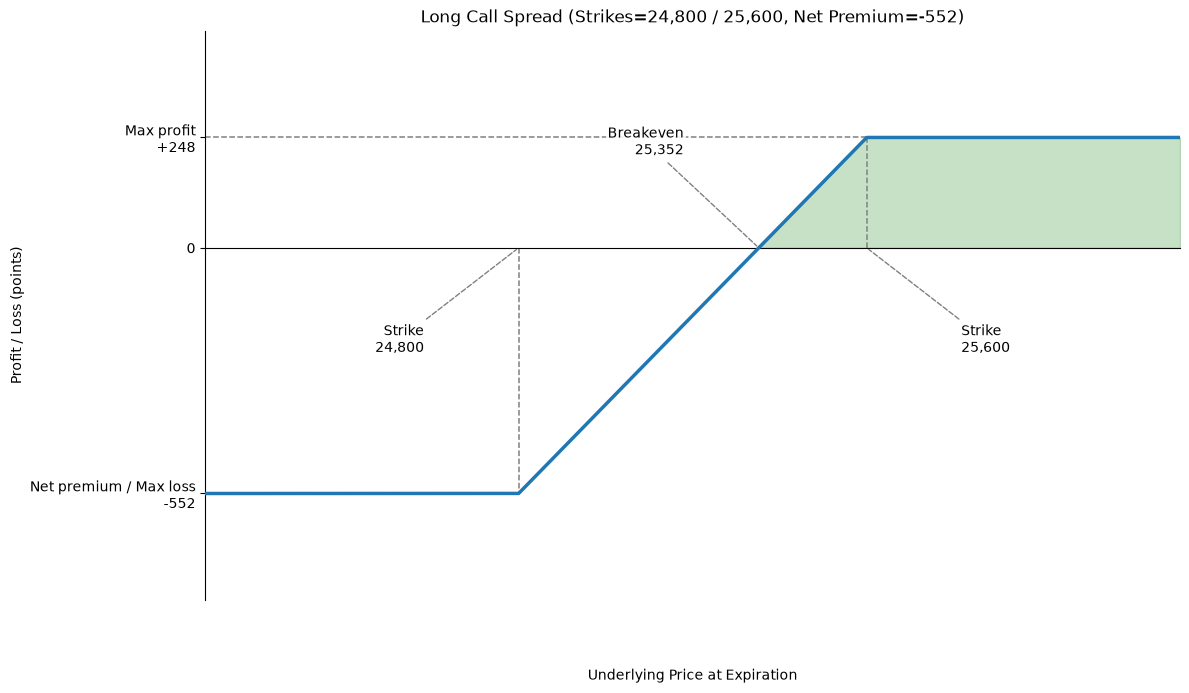

In [32]:
_quotes = df.set_index('strike_price')
_net_premium = -float(_quotes.loc[24_800, 'call_last']) + float(_quotes.loc[25_600, 'call_last'])
_max_profit = _net_premium + 800
_ = plot_option_strategy(
    'Long Call Spread',
    legs=[('call', 24_800, 1), ('call', 25_600, -1)],
    strikes=(24_800, 25_600),
    breakevens=(24_800 - _net_premium,),
    key_levels=[(_net_premium, 'Max loss'), (_max_profit, 'Max profit')],
    horizontal_guides=[(_net_premium, 24_800), (_max_profit, 25_600)],
    label_positions={
        ('Strike', 24_800): (-68, -54),
        ('Strike', 25_600): (68, -54),
    },
)


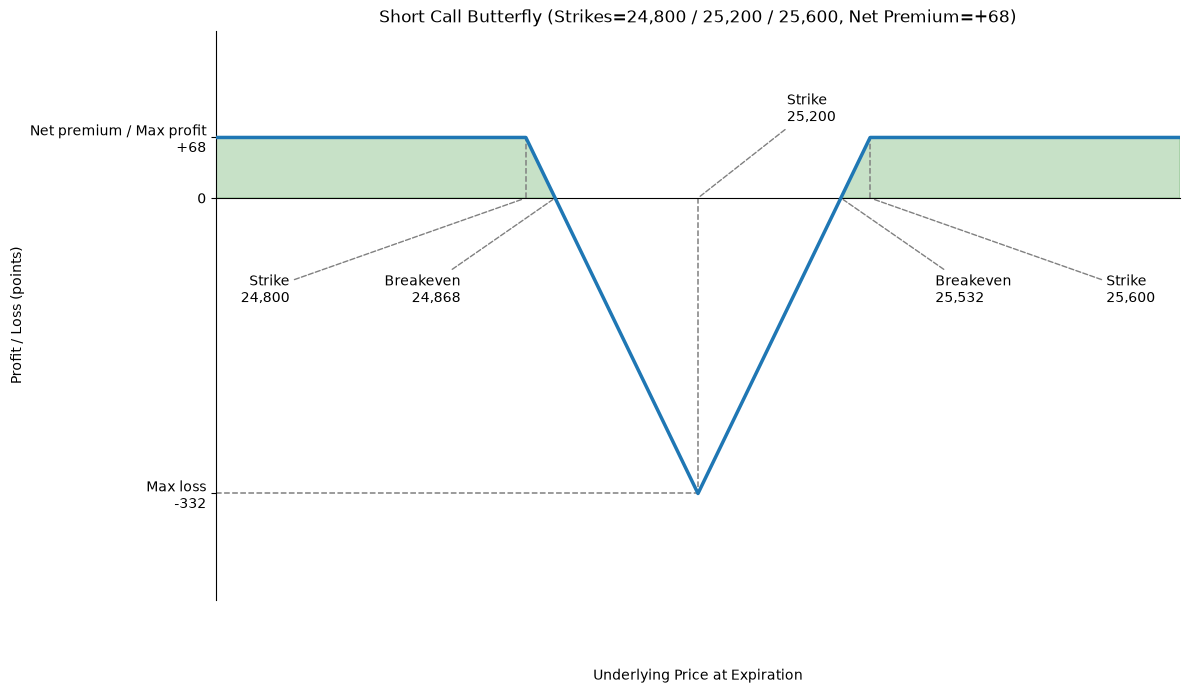

In [33]:
_quotes = df.set_index('strike_price')
_net_premium = (float(_quotes.loc[24_800, 'call_last'])
                - 2 * float(_quotes.loc[25_200, 'call_last'])
                + float(_quotes.loc[25_600, 'call_last']))
_max_loss = _net_premium - 400
_ = plot_option_strategy(
    'Short Call Butterfly',
    legs=[('call', 24_800, -1), ('call', 25_200, 2), ('call', 25_600, -1)],
    strikes=(24_800, 25_200, 25_600),
    breakevens=(24_800 + _net_premium, 25_600 - _net_premium),
    key_levels=[(_net_premium, 'Max profit'), (_max_loss, 'Max loss')],
    horizontal_guides=[(_net_premium, 24_800), (_max_loss, 25_200)],
    label_positions={
        ('Strike', 24_800): (-170, -54),
        ('Breakeven', 24_868): (-68, -54),
        ('Strike', 25_600): (170, -54),
        ('Breakeven', 25_532): (68, -54),
    },
)


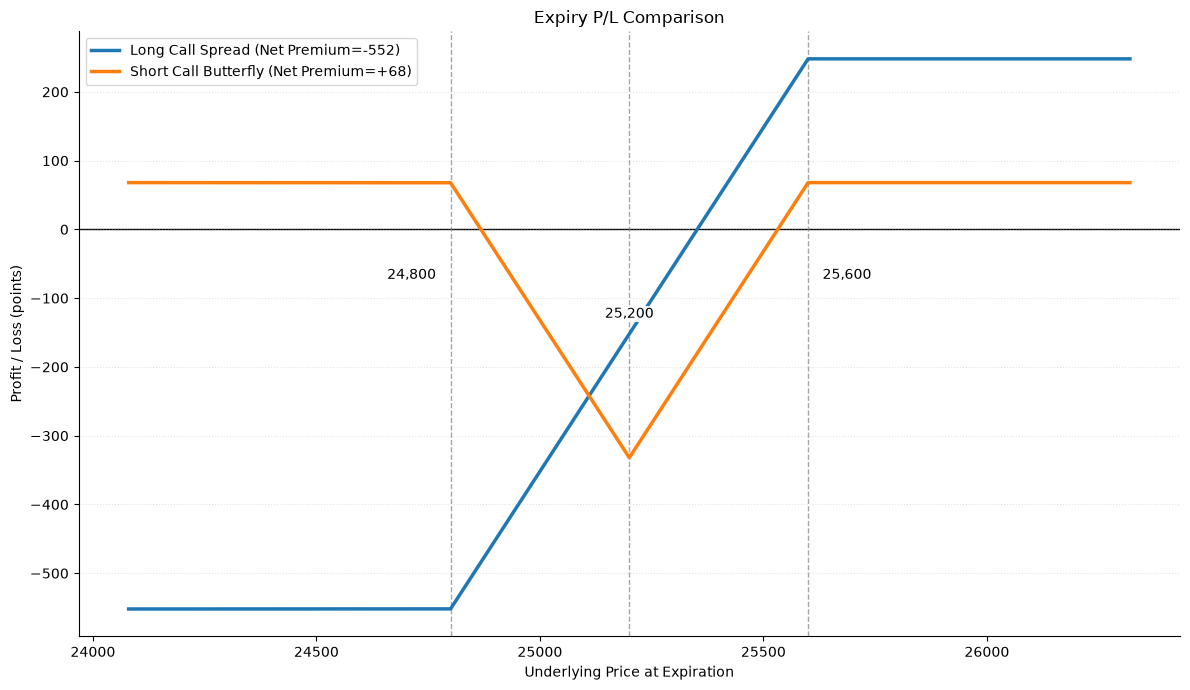

In [39]:
_q2_prices = np.linspace(24_080, 26_320, 2_001)
_q2_strategies = [
    ('Long Call Spread', [
        ('call', 24_800, 1), ('call', 25_600, -1)
    ], 'tab:blue'),
    ('Short Call Butterfly', [
        ('call', 24_800, -1), ('call', 25_200, 2), ('call', 25_600, -1)
    ], 'tab:orange'),
]

fig, ax = plt.subplots(figsize=(12, 7))
for strategy_name, legs, color in _q2_strategies:
    _net_premium, _pnl = calculate_option_strategy_pnl(legs, _q2_prices)
    ax.plot(
        _q2_prices, _pnl, color=color, linewidth=2.5,
        label=f'{strategy_name} (Net Premium={_net_premium:+,.0f})',
    )

ax.axhline(0, color='black', linewidth=1.0, zorder=0)
_q2_strike_label_offsets = {24_800: (-28, -28), 25_200: (0, -56), 25_600: (28, -28)}
for strike in (24_800, 25_200, 25_600):
    ax.axvline(strike, color='gray', linestyle='--', linewidth=1.0, alpha=0.7, zorder=0)
    ax.annotate(f'{strike:,.0f}', xy=(strike, 0), xytext=_q2_strike_label_offsets[strike],
                textcoords='offset points', ha='center', va='top',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=0.5))

ax.set_title('Expiry P/L Comparison')
ax.set_xlabel('Underlying Price at Expiration')
ax.set_ylabel('Profit / Loss (points)')
ax.legend(loc='best')
ax.grid(axis='y', linestyle=':', alpha=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
plt.show()


# 題目三：
> 假設你已知道接下來這個月股價波動劇烈，結算日時不是大好即是大壞，你很有把握股價會遠離 25,500 但不確定是大漲還是大跌，試組合出符合此假設的 strangle 、 straddle 、butterfly spread ，請將三條獲利曲線繪在同一張圖上並將圖貼到報告中， 同時解釋三個組合各由哪些選擇權構成， 另在報告中簡單比較三組合在各結算價位的優劣。

**指數是大好或大壞的情況**，核心在於不賭「方向」，而是賭「實際移動幅度會大於市場已定價的幅度」，所以使用策略：
1. Long straddle：上漲獲利無限，風險可控。
2. Long strangle：上漲獲利無限，風險可控。
3. Short butterfly：賺權利金，風險可控。

**以 call_last / put_last 為 premium，各策略組合如下：**

## Long Straddle
Long Straddle 組合為
- Long Call K；
- Long Put K。

以 $K=25,500$ 組合為
- Long 1 25,500C, Premium=486
- Long 1 25,500P, Premium=510

權利金支出 $486+510=996$。Breakeven 為 $25,500-996=24,504$ / $25,500+996=26,496$。當 $S_T < 24,504$ 或 $S_T > 26,496$ 開始獲利。

以最小虧損來看，組合為
- Long 1 25,600C, Premium=428
- Long 1 25,600P, Premium=550

權利金支出 $428+550=978$。Breakeven 為 $25,600-978=24,622$ / $25,600+978=26,578$。當 $S_T < 24,622$ 或 $S_T > 26,578$ 開始獲利。

## Long Strangle
Long Strangle 組合為
- $Long\ Put\ K_1 < 25,500$；
- $Long\ Call\ K_2 >25,500$。

以 25,500 前後一檔組合來看，即
- Long 25,400P, Premium=456
- Long 25,600C, Premium=428

權利金支出 $456+428=884$。Breakeven 為 $24,516$ / $26,484$。當 $S_T>26,484$ 或 $S_T<24,516$ 才開始獲利。

以最小虧損來看，組合為
- Long 1 24,800P, Premium=280
- Long 1 26,100C, Premium=213

權利金支出 $280+213=493$。Breakeven 為 $24,800-493=24,307$ / $26,100+493=26,593$。當 $S_T < 24,307$ 或 $S_T > 26,593$ 開始獲利。

## Short Butterfly
Short Butterfly 組合為
- Short 1 $K_1$ Call/Put
- Short 1 $K_3$ Call/Put
- Long 2 $K_2$ Call/Put

### Short Call Butterfly
以 25,500 前後一檔且以 Call 組合來看，即
- Short 1 25,400C, Premium=545
- Short 1 25,600C, Premium=428
- Long 2 25,500C, Premium=486

淨權利金=$545+428-486*2=+1$, 最大虧損=$100-1=99$。

而 $K_2=25,500$ 最大淨權利金收入則為以下組合
- Short 1 $24,900$ Call, Premium=905
- Short 1 $26,100$ Call, Premium=213
- Long 2 $25,500$ Call, Premium=486 

淨權利金=$905+213-2*486=+146$, 最大虧損=$600-146=454$。

### Short Put Butterfly
以 25,500 前後一檔且以 Put 組合來看，即
- Short 1 $25,400$ Put, Premium=456
- Short 1 $25,600$ Put, Premium=550
- Long 2 $25,500$ Put, Premium=510

淨權利金=$456+550-510*2=-14$, 最大虧損=$100-(-14)=114$。因為淨權利金為負，代表還要先付 14，所以此組合不適合。

而 $K_2=25,500$ 最大淨權利金收入則為以下組合
- Short 1 $24,900$ Put, Premium=310
- Short 1 $26,100$ Put, Premium=850
- Long 2 $25,500$ Put, Premium=510 

淨權利金=$310+850-2*510=+140$, 最大虧損=$600-140=460$。

**以 bid / ask 為 premium，各策略組合如下：**

#### Long Straddle 最小損失
- Long 25,600C @ 428；
- Long 25,600P @ 560

權利金支出：988

#### Long Strangle 最小損失
- Long 24,800P @ 285；
- Long 26,100C @ 212

總權利金支出：497

#### Short Butterfly 最大獲利
- Short 24,900P @ 306；
- Long 2 * 25,500P @ 515；
- Short 26,100P @ 825

最大獲利：101

最大損失：499



,Strategy,Contract,Strike,Premium column,Expected premium,df premium,Match
0,Long Straddle,"25,500C",25500,call_last,486,486.0,True
1,Long Straddle,"25,500P",25500,put_last,510,510.0,True
2,Long Strangle,"25,400P",25400,put_last,456,456.0,True
3,Long Strangle,"25,600C",25600,call_last,428,428.0,True
4,Short Call Butterfly,"25,400C",25400,call_last,545,545.0,True
5,Short Call Butterfly,"25,500C",25500,call_last,486,486.0,True
6,Short Call Butterfly,"25,600C",25600,call_last,428,428.0,True


Quote check passed: all supplied premiums match df.


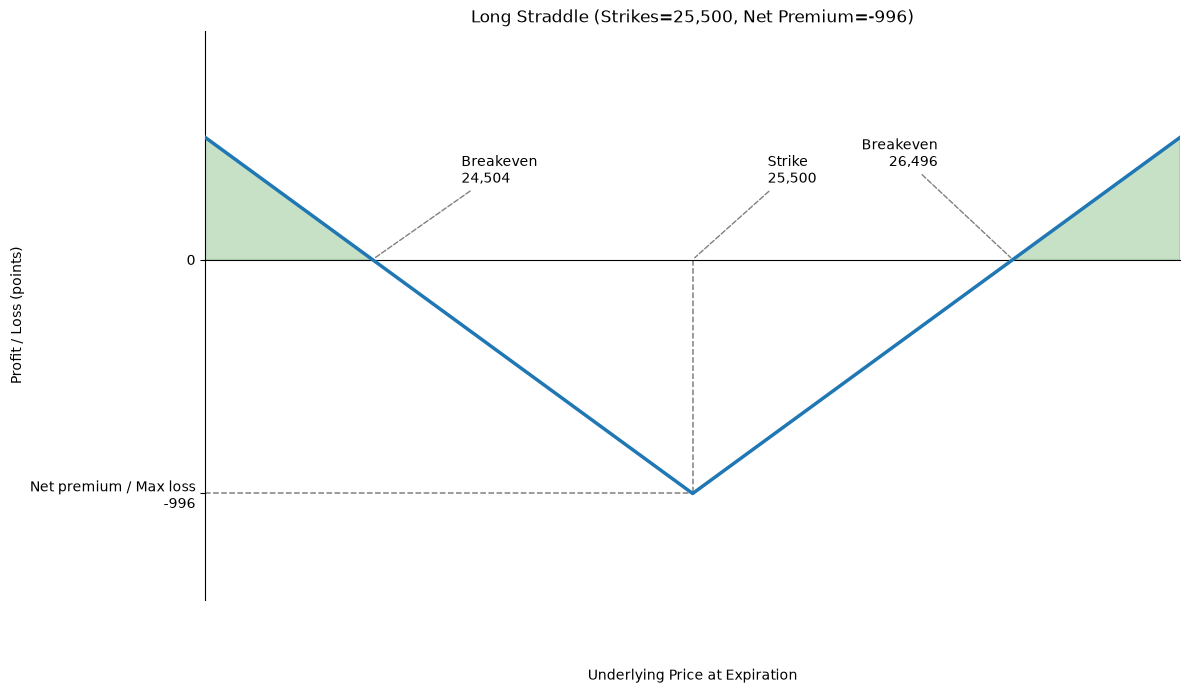

In [40]:
import warnings

_quotes = df.set_index('strike_price')
_q3_expected_quotes = [
    ('Long Straddle', '25,500C', 25_500, 'call_last', 486),
    ('Long Straddle', '25,500P', 25_500, 'put_last', 510),
    ('Long Strangle', '25,400P', 25_400, 'put_last', 456),
    ('Long Strangle', '25,600C', 25_600, 'call_last', 428),
    ('Short Call Butterfly', '25,400C', 25_400, 'call_last', 545),
    ('Short Call Butterfly', '25,500C', 25_500, 'call_last', 486),
    ('Short Call Butterfly', '25,600C', 25_600, 'call_last', 428),
]
_q3_quote_check = pd.DataFrame(
    _q3_expected_quotes,
    columns=['Strategy', 'Contract', 'Strike', 'Premium column', 'Expected premium'],
)
_q3_quote_check['df premium'] = [
    float(_quotes.loc[strike, premium_column])
    for strike, premium_column in zip(
        _q3_quote_check['Strike'], _q3_quote_check['Premium column']
    )
]
_q3_quote_check['Match'] = np.isclose(
    _q3_quote_check['Expected premium'], _q3_quote_check['df premium']
)
display(_q3_quote_check)
_q3_mismatches = _q3_quote_check.loc[~_q3_quote_check['Match']]
if _q3_mismatches.empty:
    print('Quote check passed: all supplied premiums match df.')
else:
    warnings.warn(
        f'Quote check found {len(_q3_mismatches)} mismatch(es); P/L charts use df premiums.',
        stacklevel=2,
    )
    display(_q3_mismatches)

_net_premium = -float(_quotes.loc[25_500, 'call_last']) - float(_quotes.loc[25_500, 'put_last'])
_ = plot_option_strategy(
    'Long Straddle',
    legs=[('call', 25_500, 1), ('put', 25_500, 1)],
    strikes=(25_500,),
    breakevens=(25_500 + _net_premium, 25_500 - _net_premium),
    key_levels=[(_net_premium, 'Max loss')],
    horizontal_guides=[(_net_premium, 25_500)],
)


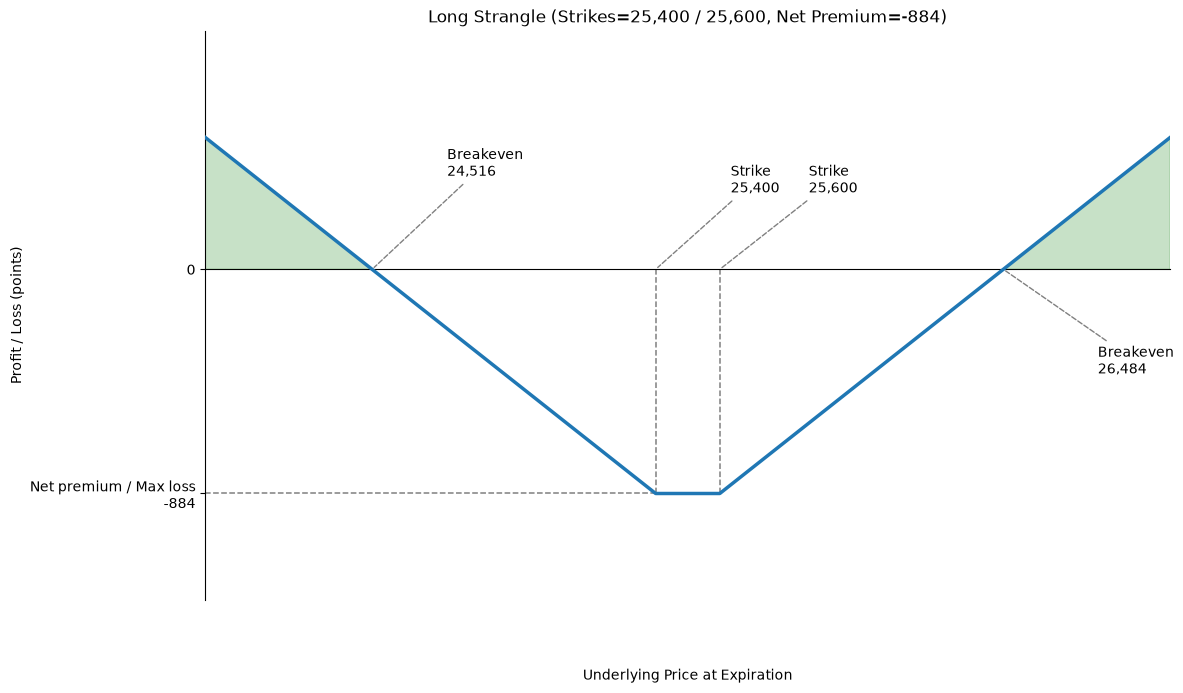

In [41]:
_quotes = df.set_index('strike_price')
_net_premium = -float(_quotes.loc[25_400, 'put_last']) - float(_quotes.loc[25_600, 'call_last'])
_ = plot_option_strategy(
    'Long Strangle',
    legs=[('put', 25_400, 1), ('call', 25_600, 1)],
    strikes=(25_400, 25_600),
    breakevens=(25_400 + _net_premium, 25_600 - _net_premium),
    key_levels=[(_net_premium, 'Max loss')],
    horizontal_guides=[(_net_premium, 25_600)],
    label_positions={('Breakeven', 25_600 - _net_premium): (68, -54)},
)


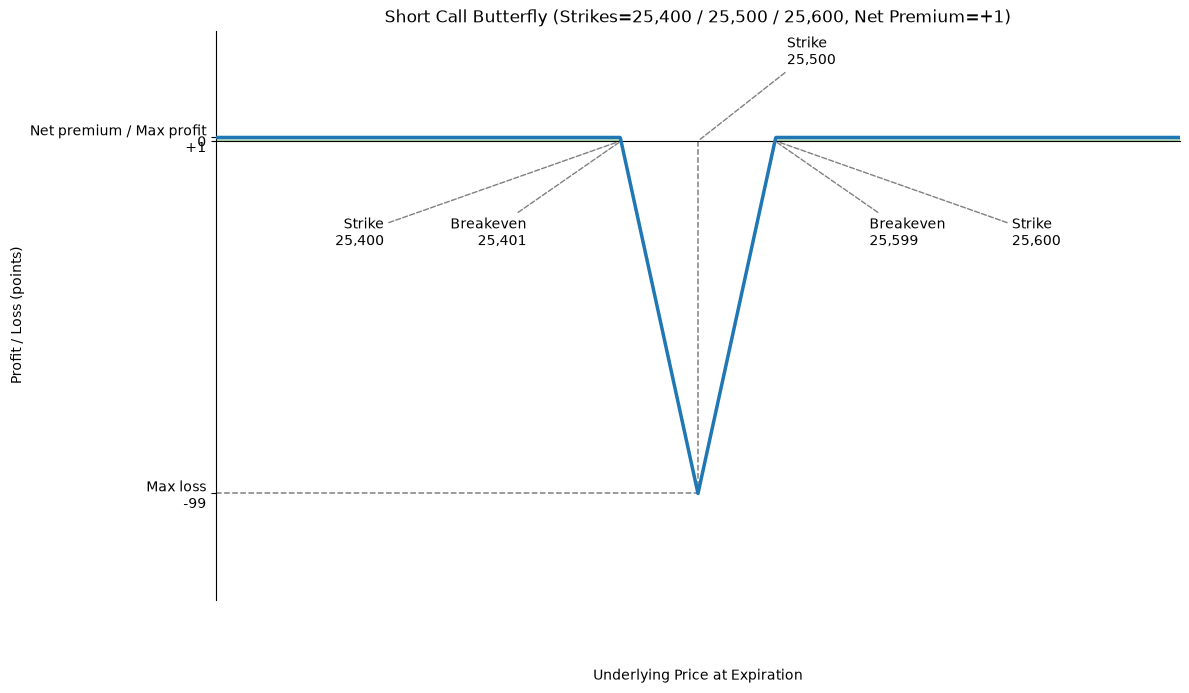

In [42]:
_quotes = df.set_index('strike_price')
_net_premium = (float(_quotes.loc[25_400, 'call_last'])
                - 2 * float(_quotes.loc[25_500, 'call_last'])
                + float(_quotes.loc[25_600, 'call_last']))
_max_loss = _net_premium - 100
_ = plot_option_strategy(
    'Short Call Butterfly',
    legs=[('call', 25_400, -1), ('call', 25_500, 2), ('call', 25_600, -1)],
    strikes=(25_400, 25_500, 25_600),
    breakevens=(25_400 + _net_premium, 25_600 - _net_premium),
    key_levels=[(_net_premium, 'Max profit'), (_max_loss, 'Max loss')],
    horizontal_guides=[(_net_premium, 25_400), (_max_loss, 25_500)],
    label_positions={
        ('Strike', 25_400): (-170, -54),
        ('Breakeven', 25_400 + _net_premium): (-68, -54),
        ('Strike', 25_600): (170, -54),
        ('Breakeven', 25_600 - _net_premium): (68, -54),
    },
)


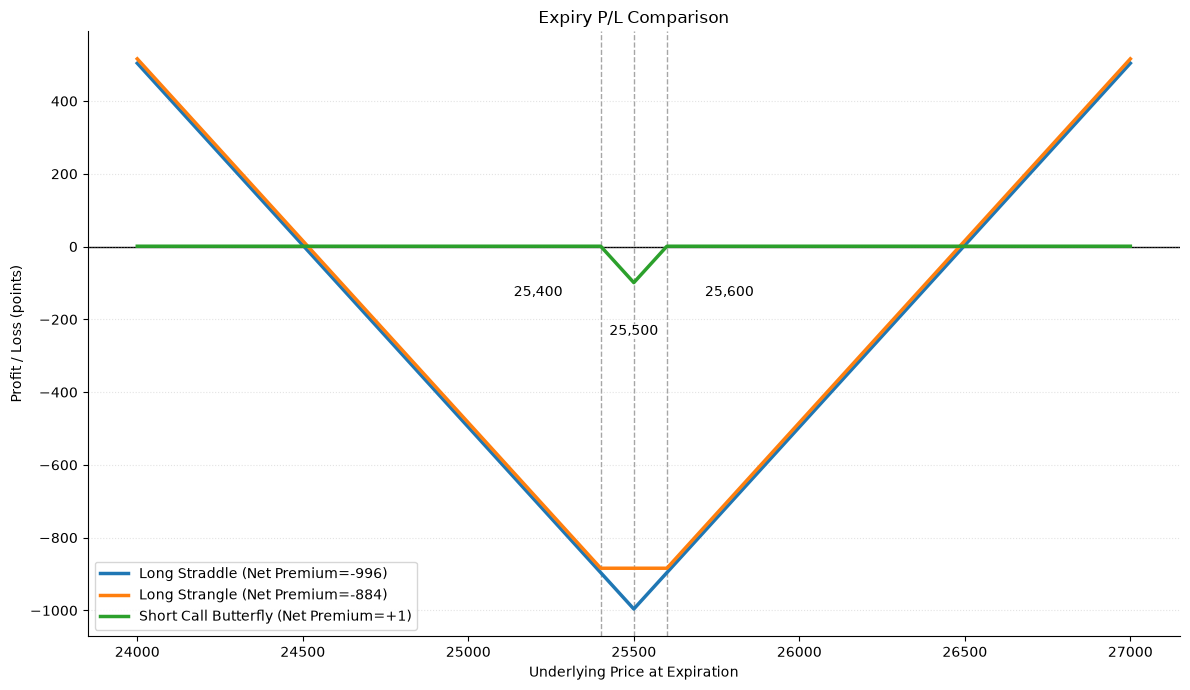

In [45]:
_q3_prices = np.linspace(24_000, 27_000, 2_001)
_q3_strategies = [
    ('Long Straddle', [('call', 25_500, 1), ('put', 25_500, 1)], 'tab:blue'),
    ('Long Strangle', [('put', 25_400, 1), ('call', 25_600, 1)], 'tab:orange'),
    ('Short Call Butterfly', [
        ('call', 25_400, -1), ('call', 25_500, 2), ('call', 25_600, -1)
    ], 'tab:green'),
]

fig, ax = plt.subplots(figsize=(12, 7))
for strategy_name, legs, color in _q3_strategies:
    _net_premium, _pnl = calculate_option_strategy_pnl(legs, _q3_prices)
    ax.plot(
        _q3_prices, _pnl, color=color, linewidth=2.5,
        label=f'{strategy_name} (Net Premium={_net_premium:+,.0f})',
    )

ax.axhline(0, color='black', linewidth=1.0, zorder=0)
_q3_strike_label_offsets = {25_400: (-45, -28), 25_500: (0, -56), 25_600: (45, -28)}
for strike in (25_400, 25_500, 25_600):
    ax.axvline(strike, color='gray', linestyle='--', linewidth=1.0, alpha=0.7, zorder=0)
    ax.annotate(f'{strike:,.0f}', xy=(strike, 0), xytext=_q3_strike_label_offsets[strike],
                textcoords='offset points', ha='center', va='top',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, pad=0.5))

ax.set_title('Expiry P/L Comparison')
ax.set_xlabel('Underlying Price at Expiration')
ax.set_ylabel('Profit / Loss (points)')
ax.legend(loc='best')
ax.grid(axis='y', linestyle=':', alpha=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
plt.show()
